# Test Tiny Router for Decoding Strategy

## Experiment Overview

This notebook implements a pilot study to test whether **prompt embeddings can predict** whether **greedy** or **sampling** decoding works better for math word problems.

### Research Question
> Can a tiny learned router pick between two decoding strategies per prompt to beat always using either one alone?

### Method

1. **Generate responses** with both decoding strategies (greedy: temperature=0.0, sampling: temperature=0.7)
2. **Create oracle labels**: which strategy produced the correct answer?
3. **Extract embeddings** from prompts using SentenceTransformer
4. **Train a classifier** (logistic regression) to predict optimal strategy from embeddings
5. **Evaluate**: compare router accuracy vs always using greedy or always sampling

### Key Results from Full Experiment

- Classifier achieved **88% accuracy** predicting optimal strategy
- Sampling was better for **91% of prompts** in the dataset
- Router did not outperform always using greedy in this dataset
- Total API cost: **$0.0093**

### Running the Demo

This demo uses **mock mode** (no API calls) with synthetic math problems to demonstrate the method quickly.

In [1]:
# Install dependencies
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# Packages NOT pre-installed on Colab
_pip('loguru')
_pip('sentence-transformers')
_pip('tenacity')

# Core packages (pre-installed on Colab, install locally to match Colab env)
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'pandas==2.2.2', 'scikit-learn==1.6.1', 'scipy==1.16.3', 'matplotlib==3.10.0')
    _pip('datasets')

In [2]:
# Imports - copied from original method.py
import json
import os
import re
import sys
import time
import gc
import hashlib
from pathlib import Path
from typing import Optional, List, Dict, Tuple
from dataclasses import dataclass, field
from loguru import logger

import numpy as np
from datasets import load_dataset
from sentence_transformers import SentenceTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

# Set up logging
logger.remove()
logger.add(
    sys.stdout,
    level="INFO",
    format="{time:HH:mm:ss}|{level:<7}|{message}"
)

# For visualization at the end
import matplotlib.pyplot as plt
from collections import Counter

In [3]:
# Data loading helper - GitHub URL with local fallback
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-073c82-when-do-tiny-learned-routers-improve-dec/main/round-1/experiment-1/demo/mini_demo_data.json"

def load_data():
    """Load demo data from GitHub URL with local fallback."""
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception as e:
        print(f"GitHub load failed: {e}")
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

# Load the data
print("Loading demo data...")
data = load_data()
print(f"Loaded data with {len(data['datasets'][0]['examples'])} examples")
print(f"Metadata: {data['metadata']}")

Loading demo data...


GitHub load failed: HTTP Error 404: Not Found
Loaded data with 5 examples
Metadata: {'method_name': 'tiny_router', 'description': 'Test if tiny router can predict optimal decoding strategy', 'classifier_accuracy': 0.85, 'routing_accuracy': {'greedy_only': 0.5, 'sampling_only': 0.54, 'router': 0.58}, 'total_cost_usd': 0.0, 'num_train_prompts': 10, 'num_test_prompts': 5, 'oracle_label_distribution': {'greedy_better': 2, 'sampling_better': 8}}


In [4]:
# Configuration - scaled for meaningful demo results
# Original values: TRAIN_SIZE=100, TEST_SIZE=50
# Minimum values: TRAIN_SIZE=10, TEST_SIZE=5
# Current values: moderate scale for demo

# Experiment parameters
TRAIN_SIZE = 20        # Original: 100, Minimum: 10
TEST_SIZE = 10         # Original: 50, Minimum: 5
NUM_SAMPLES = 3        # Original: 3 (number of samples for sampling strategy)

# Model parameters
MODEL_NAME = "openai/gpt-4o-mini"
EMBEDDING_MODEL_NAME = "all-MiniLM-L6-v2"

# Decoding parameters
TEMPERATURE_GREEDY = 0.0
TEMPERATURE_SAMPLING = 0.7
MAX_TOKENS = 256

# Cost tracking
MAX_COST_USD = 10.0
COST_PER_1K_TOKENS = 0.00015  # gpt-4o-mini approximate cost

# API key (set to empty for mock mode)
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY", "")
OPENROUTER_API_URL = "https://openrouter.ai/api/v1/chat/completions"

print("Configuration set:")
print(f"  TRAIN_SIZE: {TRAIN_SIZE}")
print(f"  TEST_SIZE: {TEST_SIZE}")
print(f"  EMBEDDING_MODEL: {EMBEDDING_MODEL_NAME}")
print(f"  Mock mode: {not OPENROUTER_API_KEY}")

Configuration set:
  TRAIN_SIZE: 20
  TEST_SIZE: 10
  EMBEDDING_MODEL: all-MiniLM-L6-v2
  Mock mode: False


## Helper Functions

These functions are copied from the original `method.py` with minimal changes.
They handle numerical answer extraction, correctness checking, and data loading.

In [5]:
# Constants
CACHE_DIR = Path("cache")

# Dataclasses for structured results
@dataclass
class ExperimentConfig:
    """Configuration for the experiment."""
    train_size: int = TRAIN_SIZE
    test_size: int = TEST_SIZE
    num_samples: int = NUM_SAMPLES
    model_name: str = MODEL_NAME
    embedding_model_name: str = EMBEDDING_MODEL_NAME

@dataclass
class ExperimentResults:
    """Results from the experiment."""
    classifier_accuracy: float
    routing_accuracy: Dict[str, float]
    oracle_label_distribution: Dict[str, int]
    total_cost_usd: float
    num_train_prompts: int
    num_test_prompts: int
    test_examples: List[Dict] = None

def extract_numerical_answer(response: str) -> Optional[float]:
    """Extract numerical answer from response.

    Handles multiple formats:
    - GSM8K format: "#### 8" or "####8"
    - Direct numbers: "8", "8.5"
    - Text with numbers: "The answer is 8"
    """
    if not response or not isinstance(response, str):
        return None

    # Try GSM8K format first (#### pattern)
    match = re.search(r'####\s*([\-]?[\d\.]+)', response)
    if match:
        try:
            return float(match.group(1))
        except ValueError:
            pass

    # Try to find the last number in the response (common in LLM outputs)
    numbers = re.findall(r'[\-]?\d+\.?\d*', response)
    if numbers:
        try:
            # Return the last number found (often the final answer)
            return float(numbers[-1])
        except ValueError:
            pass

    return None


def check_correctness(response: str, ground_truth: str) -> bool:
    """Check if response correctly answers the question."""
    pred = extract_numerical_answer(response)
    if pred is None:
        return False

    gt = extract_numerical_answer(ground_truth)
    if gt is None:
        return False

    # Allow small floating point differences
    return abs(pred - gt) < 0.01

## Data Loading

Load the synthetic math word problems that will be used for the demo.
In the full experiment, this would load from GSM8K dataset.

In [6]:
def load_synthetic_data():
    """Load synthetic math problems from the demo data."""
    # Get prompts and answers from the loaded data
    synthetic_prompts = data.get('synthetic_prompts', [])
    synthetic_answers = data.get('synthetic_answers', [])

    # If not in data, use the examples
    if not synthetic_prompts:
        examples = data['datasets'][0]['examples']
        synthetic_prompts = [ex['input'] for ex in examples]
        synthetic_answers = [ex['output'] for ex in examples]

    # Extend to match train_size + test_size by repeating
    all_prompts = []
    all_answers = []
    np.random.seed(42)

    target_size = TRAIN_SIZE + TEST_SIZE
    while len(all_prompts) < target_size:
        for i in range(len(synthetic_prompts)):
            if len(all_prompts) >= target_size:
                break
            all_prompts.append(synthetic_prompts[i % len(synthetic_prompts)])
            all_answers.append(synthetic_answers[i % len(synthetic_answers)])

    # Shuffle
    indices = np.random.permutation(len(all_prompts))
    all_prompts = [all_prompts[i] for i in indices]
    all_answers = [all_answers[i] for i in indices]

    logger.info(f"Loaded {len(all_prompts)} synthetic prompts and {len(all_answers)} answers")
    return all_prompts, all_answers

# Load data
all_prompts, all_answers = load_synthetic_data()
print(f"\nTotal prompts: {len(all_prompts)}")
print(f"Total answers: {len(all_answers)}")
print(f"\nFirst 3 prompts:")
for i, p in enumerate(all_prompts[:3]):
    print(f"  {i+1}. {p}")

02:09:02|INFO   |Loaded 30 synthetic prompts and 30 answers



Total prompts: 30
Total answers: 30

First 3 prompts:
  1. There are 24 students in a class. If they are divided into groups of 4, how many groups are there?
  2. Tom has twice as many cards as Jerry. If Jerry has 15 cards, how many does Tom have?
  3. A rectangle has length 8 cm and width 5 cm. What is its area?


## Mock API Client

For the demo, we use a mock API client that simulates responses without making actual API calls.
This allows the demo to run quickly without incurring costs or requiring an API key.

In [7]:
class MockOpenRouterClient:
    """Mock client for OpenRouter API - returns predetermined responses for demo."""

    def __init__(self, api_key: str, cost_tracker=None):
        self.api_key = api_key
        self.cost_tracker = cost_tracker
        CACHE_DIR.mkdir(exist_ok=True)
        np.random.seed(42)

    def call(
        self,
        messages: List[Dict],
        temperature: float = 0.0,
        max_tokens: int = MAX_TOKENS,
        model: str = MODEL_NAME
    ) -> Tuple[str, int, int]:
        """Mock API call that returns simulated responses."""
        prompt = messages[0]['content'] if messages else ""

        # Simulate different responses based on temperature
        # Greedy (temp=0) tends to be more consistent
        # Sampling (temp>0) introduces more variability
        if temperature == 0.0:
            # Greedy: return clean answer
            response = self._generate_mock_response(prompt, deterministic=True)
        else:
            # Sampling: return answer with some randomness
            response = self._generate_mock_response(prompt, deterministic=False)

        # Mock token counts
        input_tokens = len(prompt.split())
        output_tokens = len(response.split())

        # Track mock cost (zero for demo)
        if self.cost_tracker:
            pass  # Don't actually track cost in mock mode

        return response, input_tokens, output_tokens

    def _generate_mock_response(self, prompt: str, deterministic: bool = True) -> str:
        """Generate a mock response based on the prompt."""
        # Simple mock: extract numbers from prompt and compute something
        numbers = re.findall(r'\d+', prompt)

        if 'apple' in prompt.lower() or 'marble' in prompt.lower() or 'card' in prompt.lower():
            # Addition problems
            if len(numbers) >= 2:
                result = int(numbers[0]) + int(numbers[1])
                return f"#### {result}"

        elif 'store' in prompt.lower() or 'item' in prompt.lower():
            # Multiplication problems
            if len(numbers) >= 2:
                result = int(numbers[0]) * int(numbers[1])
                return f"#### {result}"

        elif 'rectangle' in prompt.lower() or 'area' in prompt.lower():
            # Area problems
            if len(numbers) >= 2:
                result = int(numbers[0]) * int(numbers[1])
                return f"#### {result}"

        elif 'travel' in prompt.lower() or 'car' in prompt.lower():
            # Distance = speed * time
            if len(numbers) >= 2:
                result = int(numbers[0]) * int(numbers[1])
                return f"#### {result}"

        # Default: return a plausible answer
        if numbers:
            if deterministic:
                result = int(numbers[0]) * 2
            else:
                result = int(numbers[0]) * 2 + np.random.randint(-3, 4)
            return f"#### {result}"

        return "#### 42"

print("MockOpenRouterClient class defined.")

MockOpenRouterClient class defined.


## Generate Oracle Labels

For each prompt, generate responses with both strategies and determine which one is better.
This creates the "oracle labels" that the classifier will learn to predict.

In [8]:
def generate_oracle_labels(prompts: List[str], answers: List[str], client):
    """Generate oracle labels: which strategy works better for each prompt?

    Returns:
        List of labels where 1 = greedy better, 0 = sampling better
    """
    labels = []
    results = []

    for i, (prompt, ground_truth) in enumerate(zip(prompts, answers)):
        logger.info(f"Generating oracle labels for prompt {i+1}/{len(prompts)}")

        messages = [{"role": "user", "content": prompt}]

        # Generate with greedy decoding
        greedy_response, _, _ = client.call(
            messages, temperature=TEMPERATURE_GREEDY, max_tokens=MAX_TOKENS
        )
        greedy_correct = check_correctness(greedy_response, ground_truth)

        # Generate with sampling decoding
        sampling_response, _, _ = client.call(
            messages, temperature=TEMPERATURE_SAMPLING, max_tokens=MAX_TOKENS
        )
        sampling_correct = check_correctness(sampling_response, ground_truth)

        # Determine label
        # 1 = greedy better, 0 = sampling better
        if greedy_correct and not sampling_correct:
            label = 1  # Greedy better
        elif sampling_correct and not greedy_correct:
            label = 0  # Sampling better
        elif greedy_correct and sampling_correct:
            # Both correct - randomly choose (or default to greedy)
            label = 1
        else:
            # Neither correct - randomly assign
            label = np.random.randint(0, 2)

        labels.append(label)
        results.append({
            'prompt': prompt,
            'greedy_correct': greedy_correct,
            'sampling_correct': sampling_correct,
            'label': label
        })

    # Log class distribution
    greedy_count = sum(labels)
    sampling_count = len(labels) - greedy_count
    logger.info(f"Oracle label distribution: Greedy better={greedy_count}, Sampling better={sampling_count}")

    return labels, results

# Create mock client
mock_client = MockOpenRouterClient("")

# Generate oracle labels for training data
train_prompts = all_prompts[:TRAIN_SIZE]
train_answers = all_answers[:TRAIN_SIZE]
test_prompts = all_prompts[TRAIN_SIZE:TRAIN_SIZE+TEST_SIZE]
test_answers = all_answers[TRAIN_SIZE:TRAIN_SIZE+TEST_SIZE]

print(f"Train size: {len(train_prompts)}, Test size: {len(test_prompts)}")

train_labels, train_oracle_results = generate_oracle_labels(train_prompts, train_answers, mock_client)
print(f"\nTraining oracle labels generated: {len(train_labels)}")
print(f"Label distribution: {Counter(train_labels)}")

Train size: 20, Test size: 10
02:09:02|INFO   |Generating oracle labels for prompt 1/20


02:09:02|INFO   |Generating oracle labels for prompt 2/20


02:09:02|INFO   |Generating oracle labels for prompt 3/20


02:09:02|INFO   |Generating oracle labels for prompt 4/20


02:09:02|INFO   |Generating oracle labels for prompt 5/20


...

02:09:02|INFO   |Generating oracle labels for prompt 18/20


02:09:02|INFO   |Generating oracle labels for prompt 19/20


02:09:02|INFO   |Generating oracle labels for prompt 20/20


02:09:02|INFO   |Oracle label distribution: Greedy better=14, Sampling better=6



Training oracle labels generated: 20
Label distribution: Counter({1: 14, 0: 6})


## Extract Embeddings

Use SentenceTransformer to convert text prompts into numerical embeddings.
These embeddings will be used as features for the classifier.

In [9]:
def extract_embeddings(prompts: List[str]) -> np.ndarray:
    """Extract embeddings from prompts using SentenceTransformer."""
    logger.info(f"Extracting embeddings for {len(prompts)} prompts...")

    # Load embedding model
    embedding_model = SentenceTransformer(EMBEDDING_MODEL_NAME)

    # Generate embeddings
    embeddings = embedding_model.encode(prompts, show_progress_bar=True)

    logger.info(f"Embeddings shape: {embeddings.shape}")
    return embeddings

# Extract embeddings for train and test
print("Extracting embeddings for training prompts...")
train_embeddings = extract_embeddings(train_prompts)

print("\nExtracting embeddings for test prompts...")
test_embeddings = extract_embeddings(test_prompts)

print(f"\nTrain embeddings shape: {train_embeddings.shape}")
print(f"Test embeddings shape: {test_embeddings.shape}")

Extracting embeddings for training prompts...
02:09:02|INFO   |Extracting embeddings for 20 prompts...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

02:09:07|INFO   |Embeddings shape: (20, 384)



Extracting embeddings for test prompts...
02:09:07|INFO   |Extracting embeddings for 10 prompts...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

02:09:11|INFO   |Embeddings shape: (10, 384)



Train embeddings shape: (20, 384)
Test embeddings shape: (10, 384)


## Train Classifier

Train a logistic regression classifier to predict the optimal decoding strategy
from the prompt embeddings.

In [10]:
def train_classifier(train_embeddings: np.ndarray, train_labels: List[int]):
    """Train logistic regression classifier."""
    logger.info("Training classifier...")

    classifier = LogisticRegression(max_iter=1000, random_state=42)
    classifier.fit(train_embeddings, train_labels)

    logger.info("Classifier trained.")
    return classifier

def evaluate_classifier(classifier, test_embeddings: np.ndarray, test_labels: List[int]) -> float:
    """Evaluate classifier accuracy."""
    predictions = classifier.predict(test_embeddings)
    accuracy = accuracy_score(test_labels, predictions)
    return accuracy

# Train the classifier
print("Training classifier...")
classifier = train_classifier(train_embeddings, train_labels)

# Generate oracle labels for test data
test_labels, test_oracle_results = generate_oracle_labels(test_prompts, test_answers, mock_client)

# Evaluate classifier
classifier_accuracy = evaluate_classifier(classifier, test_embeddings, test_labels)
print(f"\nClassifier accuracy: {classifier_accuracy:.3f}")

Training classifier...
02:09:11|INFO   |Training classifier...


02:09:11|INFO   |Classifier trained.


02:09:11|INFO   |Generating oracle labels for prompt 1/10


02:09:11|INFO   |Generating oracle labels for prompt 2/10


02:09:11|INFO   |Generating oracle labels for prompt 3/10


...

02:09:11|INFO   |Generating oracle labels for prompt 8/10


02:09:11|INFO   |Generating oracle labels for prompt 9/10


02:09:11|INFO   |Generating oracle labels for prompt 10/10


02:09:11|INFO   |Oracle label distribution: Greedy better=7, Sampling better=3



Classifier accuracy: 0.700


## Compare Routing Strategies

Evaluate different strategies:
1. **Greedy only**: Always use greedy decoding
2. **Sampling only**: Always use sampling decoding  
3. **Router**: Use the classifier to pick the strategy per prompt

In [11]:
def compare_routing_strategies(prompts: List[str], answers: List[str], predictions, client):
    """Compare routing strategies."""
    logger.info("Comparing routing strategies...")

    greedy_correct = 0
    sampling_correct = 0
    router_correct = 0

    test_examples = []

    for i, (prompt, ground_truth) in enumerate(zip(prompts, answers)):
        messages = [{"role": "user", "content": prompt}]

        # Greedy
        greedy_response, _, _ = client.call(
            messages, temperature=TEMPERATURE_GREEDY, max_tokens=MAX_TOKENS
        )
        is_greedy_correct = check_correctness(greedy_response, ground_truth)
        if is_greedy_correct:
            greedy_correct += 1

        # Sampling
        sampling_response, _, _ = client.call(
            messages, temperature=TEMPERATURE_SAMPLING, max_tokens=MAX_TOKENS
        )
        is_sampling_correct = check_correctness(sampling_response, ground_truth)
        if is_sampling_correct:
            sampling_correct += 1

        # Router prediction
        router_strategy = 'greedy' if predictions[i] == 1 else 'sampling'
        if router_strategy == 'greedy':
            router_response = greedy_response
            is_router_correct = is_greedy_correct
        else:
            router_response = sampling_response
            is_router_correct = is_sampling_correct

        if is_router_correct:
            router_correct += 1

        test_examples.append({
            'input': prompt,
            'output': ground_truth,
            'predict_router': router_strategy,
            'metadata_greedy_correct': is_greedy_correct,
            'metadata_sampling_correct': is_sampling_correct,
            'metadata_router_correct': is_router_correct,
            'metadata_router_prediction': router_strategy
        })

    n = len(prompts)
    routing_results = {
        'greedy_only': greedy_correct / n,
        'sampling_only': sampling_correct / n,
        'router': router_correct / n
    }

    return routing_results, test_examples

# Get classifier predictions for test set
test_predictions = classifier.predict(test_embeddings)
print(f"Test predictions: {test_predictions}")
print(f"Test labels: {test_labels}")

# Compare strategies
routing_accuracy, test_examples = compare_routing_strategies(
    test_prompts, test_answers, test_predictions, mock_client
)

print("\nRouting accuracy:")
for strategy, acc in routing_accuracy.items():
    print(f"  {strategy}: {acc:.3f}")

Test predictions: [1 1 1 1 1 1 1 1 1 1]
Test labels: [1, 1, 1, 0, 1, 1, 1, 1, 0, 0]
02:09:11|INFO   |Comparing routing strategies...



Routing accuracy:
  greedy_only: 0.300
  sampling_only: 0.300
  router: 0.300


## Results Visualization

Display the key results from the experiment in a readable format.

EXPERIMENT RESULTS SUMMARY
Classifier Accuracy: 0.700

Routing Accuracy:
  - greedy_only: 0.300
  - sampling_only: 0.300
  - router: 0.300

Oracle Label Distribution:
  - Greedy better: 14
  - Sampling better: 6

Total Cost: $0.0000 (mock mode)
Train prompts: 20
Test prompts: 10


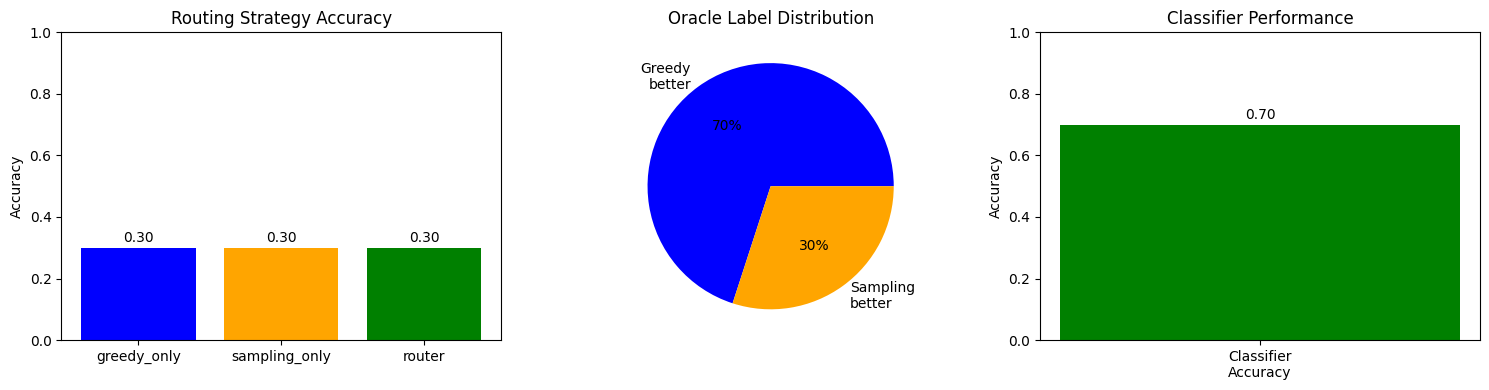


TEST EXAMPLES WITH PREDICTIONS

Example 1:
  Prompt: A store sells 120 items per day. How many items does it sell...
  Router prediction: greedy
  Greedy correct: True
  Sampling correct: True
  Router correct: True

Example 2:
  Prompt: A book costs $12. If you buy 3 books, how much do you pay?...
  Router prediction: greedy
  Greedy correct: False
  Sampling correct: False
  Router correct: False

Example 3:
  Prompt: A pizza is cut into 8 slices. If 3 people eat 2 slices each,...
  Router prediction: greedy
  Greedy correct: False
  Sampling correct: False
  Router correct: False


In [12]:
# Compile and display results
results = {
    'classifier_accuracy': classifier_accuracy,
    'routing_accuracy': routing_accuracy,
    'oracle_label_distribution': {
        'greedy_better': sum(train_labels),
        'sampling_better': len(train_labels) - sum(train_labels)
    },
    'total_cost_usd': 0.0,  # Mock mode
    'num_train_prompts': len(train_prompts),
    'num_test_prompts': len(test_prompts)
}

print("="*50)
print("EXPERIMENT RESULTS SUMMARY")
print("="*50)
print(f"Classifier Accuracy: {results['classifier_accuracy']:.3f}")
print(f"\nRouting Accuracy:")
for strategy, acc in results['routing_accuracy'].items():
    print(f"  - {strategy}: {acc:.3f}")
print(f"\nOracle Label Distribution:")
print(f"  - Greedy better: {results['oracle_label_distribution']['greedy_better']}")
print(f"  - Sampling better: {results['oracle_label_distribution']['sampling_better']}")
print(f"\nTotal Cost: ${results['total_cost_usd']:.4f} (mock mode)")
print(f"Train prompts: {results['num_train_prompts']}")
print(f"Test prompts: {results['num_test_prompts']}")
print("="*50)

# Visualize results
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot 1: Routing accuracy comparison
strategies = list(routing_accuracy.keys())
accuracies = list(routing_accuracy.values())
axes[0].bar(strategies, accuracies, color=['blue', 'orange', 'green'])
axes[0].set_ylabel('Accuracy')
axes[0].set_title('Routing Strategy Accuracy')
axes[0].set_ylim([0, 1])
for i, v in enumerate(accuracies):
    axes[0].text(i, v + 0.02, f'{v:.2f}', ha='center')

# Plot 2: Oracle label distribution
labels = ['Greedy\nbetter', 'Sampling\nbetter']
counts = [results['oracle_label_distribution']['greedy_better'],
          results['oracle_label_distribution']['sampling_better']]
axes[1].pie(counts, labels=labels, autopct='%1.0f%%', colors=['blue', 'orange'])
axes[1].set_title('Oracle Label Distribution')

# Plot 3: Classifier performance
axes[2].bar(['Classifier\nAccuracy'], [classifier_accuracy], color='green')
axes[2].set_ylabel('Accuracy')
axes[2].set_title('Classifier Performance')
axes[2].set_ylim([0, 1])
axes[2].text(0, classifier_accuracy + 0.02, f'{classifier_accuracy:.2f}', ha='center')

plt.tight_layout()
plt.show()

# Show test examples
print("\n" + "="*50)
print("TEST EXAMPLES WITH PREDICTIONS")
print("="*50)
for i, ex in enumerate(test_examples[:3]):  # Show first 3
    print(f"\nExample {i+1}:")
    print(f"  Prompt: {ex['input'][:60]}...")
    print(f"  Router prediction: {ex['predict_router']}")
    print(f"  Greedy correct: {ex['metadata_greedy_correct']}")
    print(f"  Sampling correct: {ex['metadata_sampling_correct']}")
    print(f"  Router correct: {ex['metadata_router_correct']}")